In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [3]:
DATA_PATH = "smart_grid_load_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,timestamp,load_MW,temperature_C,humidity,wind_speed,hour,day_of_week,is_weekend,lag_1,lag_24,rolling_mean_3
0,2022-01-01 00:00:00,30548.354221,9.228418,76.640011,4.562699,0,5,1,NaN,NaN,NaN
1,2022-01-01 01:00:00,31207.470993,12.197539,67.038840,5.765877,1,5,1,30548.354221,NaN,NaN
2,2022-01-01 02:00:00,33199.328607,9.775760,69.334136,6.470284,2,5,1,31207.470993,NaN,31651.717940
3,2022-01-01 03:00:00,35110.203831,10.353272,68.246176,2.633271,3,5,1,33199.328607,NaN,33172.334477
4,2022-01-01 04:00:00,34147.613713,11.606915,75.140537,5.201478,4,5,1,35110.203831,NaN,34152.382050


In [4]:
# --- Schema checks & time-series validation ---
expected_cols = {
    "timestamp", "load_MW", "temperature_C", "humidity", "wind_speed",
    "hour", "day_of_week", "is_weekend",
    "lag_1", "lag_24", "rolling_mean_3",
}

missing_expected = sorted(list(expected_cols - set(df_raw.columns)))
extra_cols = sorted(list(set(df_raw.columns) - expected_cols))

print("Missing expected columns:", missing_expected)
print("Extra columns:", extra_cols)

df = df_raw.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

dup_ts = df["timestamp"].duplicated().sum()
nan_ts = df["timestamp"].isna().sum()
print(f"Timestamp parse NaNs: {nan_ts}")
print(f"Duplicate timestamps: {dup_ts}")

# Drop rows where timestamp couldn't be parsed
df = df.dropna(subset=["timestamp"]).copy()

# Sort by time (critical for lag/rolling and time-based splits)
df = df.sort_values("timestamp").reset_index(drop=True)

print("Rows after timestamp parse:", len(df))

# Frequency/gap check (expected: hourly)
time_deltas = df["timestamp"].diff().dropna()
mode_delta = time_deltas.mode().iloc[0]
non_hourly = (time_deltas != mode_delta).sum()
print("Most common delta:", mode_delta)
print("Non-common-delta count:", non_hourly)

core_feature_cols = [
    "temperature_C", "humidity", "wind_speed", "hour", "day_of_week", "is_weekend",
    "lag_1", "lag_24", "rolling_mean_3",
]

print("Missing values per column (top):")
print(df[["load_MW"] + core_feature_cols].isna().sum().sort_values(ascending=False).head(15))


Missing expected columns: []
Extra columns: []
Timestamp parse NaNs: 0
Duplicate timestamps: 0
Rows after timestamp parse: 40000
Most common delta: 0 days 01:00:00
Non-common-delta count: 0
Missing values per column (top):
load_MW           200
temperature_C     200
lag_24             24
rolling_mean_3      2
lag_1               1
humidity            0
day_of_week         0
hour                0
wind_speed          0
is_weekend          0
dtype: int64


In [5]:
# --- Derived feature verification (avoid leakage) ---
# Recompute lag/rolling using a safe definition based on sorted time.
df_check = df[["timestamp", "load_MW"]].copy()
df_check["lag_1_calc"] = df_check["load_MW"].shift(1)
df_check["lag_24_calc"] = df_check["load_MW"].shift(24)
df_check["rolling_mean_3_calc"] = (
    df_check["load_MW"].shift(1).rolling(window=3, min_periods=3).mean()
)

compare_cols = [
    ("lag_1", "lag_1_calc"),
    ("lag_24", "lag_24_calc"),
    ("rolling_mean_3", "rolling_mean_3_calc"),
]

report_rows = []
TOL = 1e-6
for provided_col, calc_col in compare_cols:
    provided = df[provided_col]
    calc = df_check[calc_col]
    mask = (~provided.isna()) & (~calc.isna())
    if mask.sum() == 0:
        report_rows.append({
            "feature": provided_col,
            "n_compared": 0,
            "max_abs_diff": np.nan,
            "mean_abs_diff": np.nan,
            "pct_within_tol": np.nan,
        })
        continue
    diffs = (provided[mask] - calc[mask]).abs()
    report_rows.append({
        "feature": provided_col,
        "n_compared": int(mask.sum()),
        "max_abs_diff": float(diffs.max()),
        "mean_abs_diff": float(diffs.mean()),
        "pct_within_tol": float((diffs <= TOL).mean() * 100.0),
    })

pd.DataFrame(report_rows).sort_values("feature")

,feature,n_compared,max_abs_diff,mean_abs_diff,pct_within_tol
0,lag_1,39799,0.000000,0.000000,100.0
1,lag_24,39776,0.000000,0.000000,100.0
2,rolling_mean_3,39398,2983.343594,871.044819,0.0


In [6]:
# Use the safe recomputed versions for modeling.
df["lag_1"] = df_check["lag_1_calc"]
df["lag_24"] = df_check["lag_24_calc"]
df["rolling_mean_3"] = df_check["rolling_mean_3_calc"]

del df_check

print("Core feature columns used:")
print(core_feature_cols)


Core feature columns used:
['temperature_C', 'humidity', 'wind_speed', 'hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_3']


EXPLORATORY DATA ANALYSIS


In [7]:
# --- Missingness overview ---
target_col = "load_MW"

eda_cols = [target_col] + core_feature_cols
missing_counts = df[eda_cols].isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100.0).round(2)

missing_table = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_table

,missing_count,missing_pct
rolling_mean_3,602,1.50
lag_24,224,0.56
lag_1,201,0.50
load_MW,200,0.50
temperature_C,200,0.50
humidity,0,0.00
day_of_week,0,0.00
hour,0,0.00
wind_speed,0,0.00
is_weekend,0,0.00


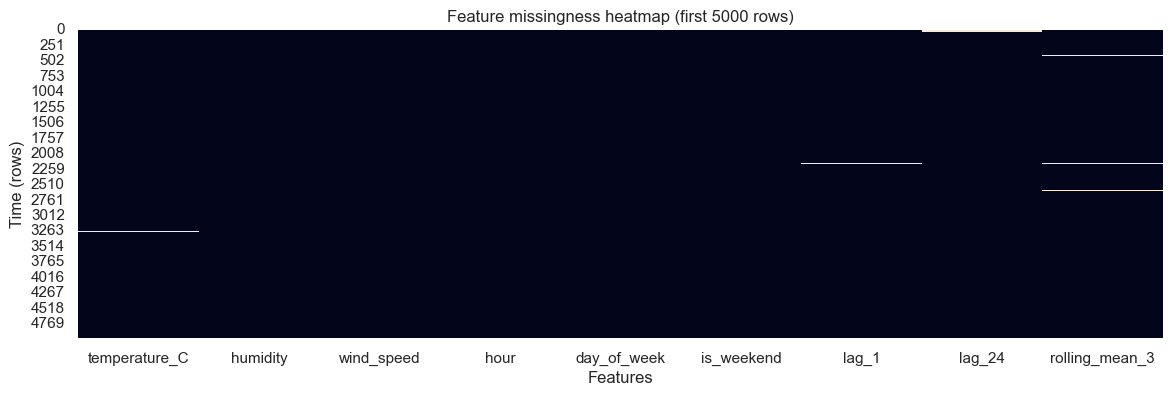

In [10]:
# Missingness heatmap (zoomed to early rows where lags/rolling are naturally missing)
zoom_n = 5000

zoom_df = df[core_feature_cols].head(zoom_n)

plt.figure(figsize=(14, 4))
sns.heatmap(zoom_df.isna(), cbar=False)
plt.title(f"Feature missingness heatmap (first {zoom_n} rows)")
plt.xlabel("Features")
plt.ylabel("Time (rows)")
plt.show()


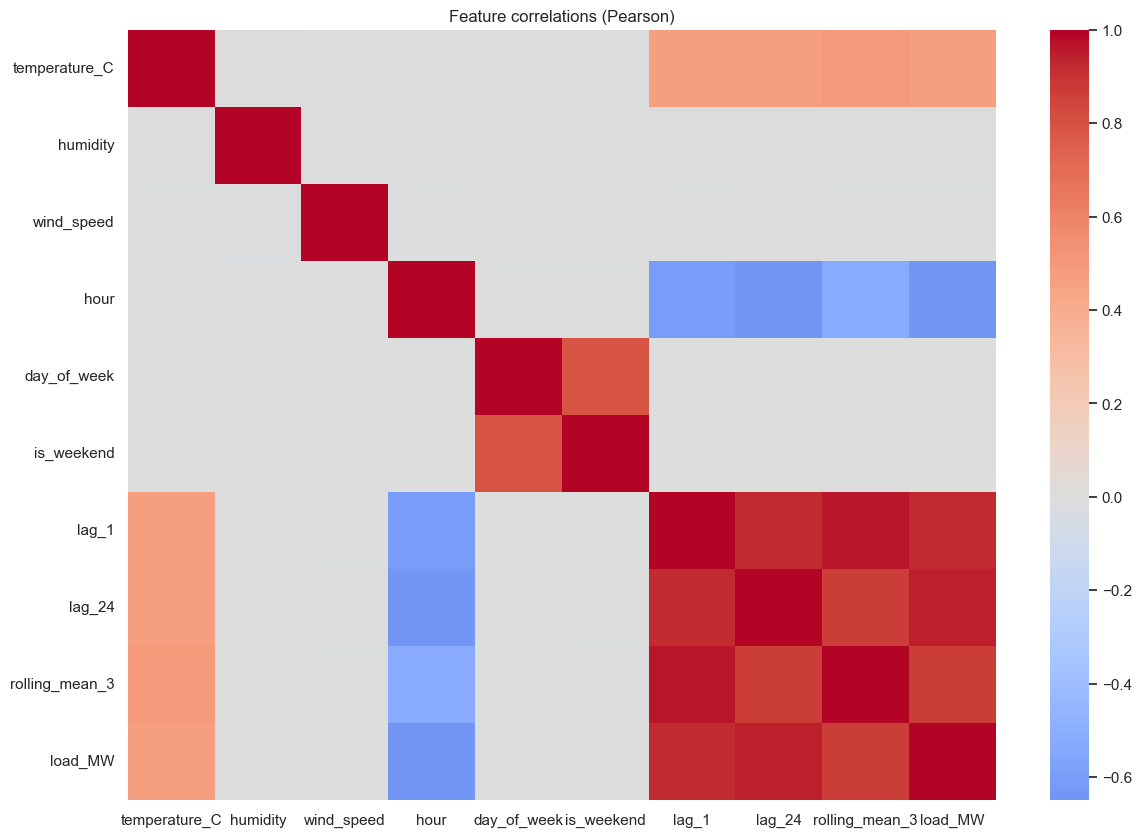

,corr_with_load_MW
lag_24,0.944347
lag_1,0.920122
rolling_mean_3,0.866800
hour,-0.648339
temperature_C,0.474936
humidity,0.003130
is_weekend,0.001889
wind_speed,-0.001178
day_of_week,0.000707


In [11]:
# --- Correlation matrix (Pearson) ---
corr_cols = core_feature_cols + [target_col]
corr = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlations (Pearson)")
plt.show()

# Top correlations with target
target_corr = corr[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
target_corr.head(15).to_frame("corr_with_load_MW")

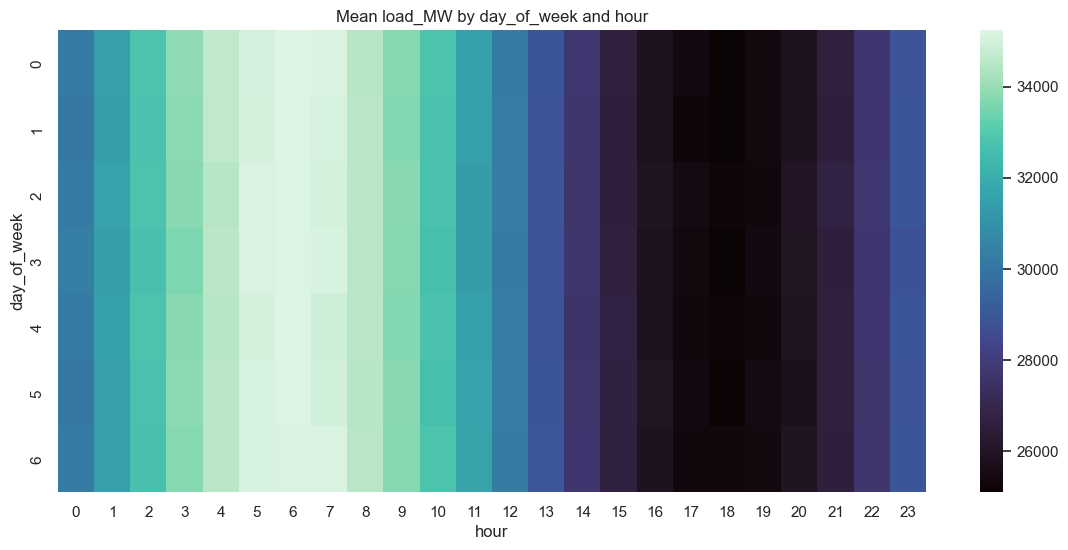

In [12]:
# --- Heatmap: mean load by hour and day_of_week ---
pivot = df.pivot_table(
    index="day_of_week",
    columns="hour",
    values=target_col,
    aggfunc="mean",
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="mako")
plt.title("Mean load_MW by day_of_week and hour")
plt.xlabel("hour")
plt.ylabel("day_of_week")
plt.show()


In [ ]:
# --- Feature-target relationships (scatter + trend) ---
weather_cols = ["temperature_C", "humidity", "wind_speed"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, weather_cols):
    tmp = df[[col, target_col]].dropna()
    tmp = tmp.sample(n=min(15000, len(tmp)), random_state=RANDOM_STATE) if len(tmp) > 2 else tmp
    sns.regplot(
        data=tmp,
        x=col,
        y=target_col,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"color": "crimson", "linewidth": 2},
        ax=ax,
    )
    ax.set_title(f"{col} vs load_MW")

plt.tight_layout()
plt.show()
